# Decision Tree

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

## Importig the Dataset

In [2]:
df = pd.read_csv('/workspaces/Supervised-Machine-Learning/Datasets/iphone_purchase_records.csv')

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (400, 3)
Shape of y: (400,)


## Applying LabelEncoder

In [4]:
encoder = LabelEncoder()
X[:, 0] = encoder.fit_transform(X[:, 0])

X = X.astype(float)

## Splitting the Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324)

## Implementing Classifier Model

In [6]:
class DT_classifier:
    def __init__(self, x_train: np.ndarray, y_train: np.ndarray,
                  x_test: np.ndarray, y_test: np.ndarray, 
                  max_depth: int = 5, criterion: str = 'gini'):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test

        self.max_depth = max_depth
        self.criterion = criterion

        self.classifier = DecisionTreeClassifier(max_depth=self.max_depth, criterion=self.criterion)
        self.classifier.fit(self.x_train, self.y_train)

        self.y_pred = self.classifier.predict(self.x_test)
        self.test_accuracy = accuracy_score(self.y_test, self.y_pred)
        self.train_accuracy = accuracy_score(self.y_train, self.classifier.predict(self.x_train))

    def getReport(self):
        return classification_report(self.y_test, self.y_pred),confusion_matrix(self.y_test, self.y_pred), self.test_accuracy, self.train_accuracy

## Criterion GINI

In [7]:
max_depth = range(2,11,2)
train_df = pd.DataFrame(columns=['Max Depth', 'Criterion', 'Test_Accuracy', 'Train_Accuracy', 'Classification Report', 'Confusion Matrix'])

trained_models = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(DT_classifier)(X_train, y_train, X_test, y_test, max_depth=depth) for depth in max_depth
)

for model in trained_models:
    cr, cm, test_acc, train_acc = model.getReport()
    train_df = pd.concat([train_df, pd.DataFrame({
        'Max Depth': [model.max_depth],
        'Criterion': [model.criterion],
        'Test_Accuracy': [test_acc],
        'Train_Accuracy': [train_acc],
        'Classification Report': [cr],
        'Confusion Matrix': [cm]
    })], ignore_index=True)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.5s finished
/tmp/ipykernel_50123/40054312.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat([train_df, pd.DataFrame({


In [8]:
display(train_df)

,Max Depth,Criterion,Test_Accuracy,Train_Accuracy,Classification Report,Confusion Matrix
0,2,gini,0.9250,0.909375,precision recall f1-score ...,"[[44, 6], [0, 30]]"
1,4,gini,0.9000,0.921875,precision recall f1-score ...,"[[46, 4], [4, 26]]"
2,6,gini,0.8875,0.953125,precision recall f1-score ...,"[[45, 5], [4, 26]]"
3,8,gini,0.8750,0.975000,precision recall f1-score ...,"[[45, 5], [5, 25]]"
4,10,gini,0.8875,0.984375,precision recall f1-score ...,"[[46, 4], [5, 25]]"


### Plotting the outcome

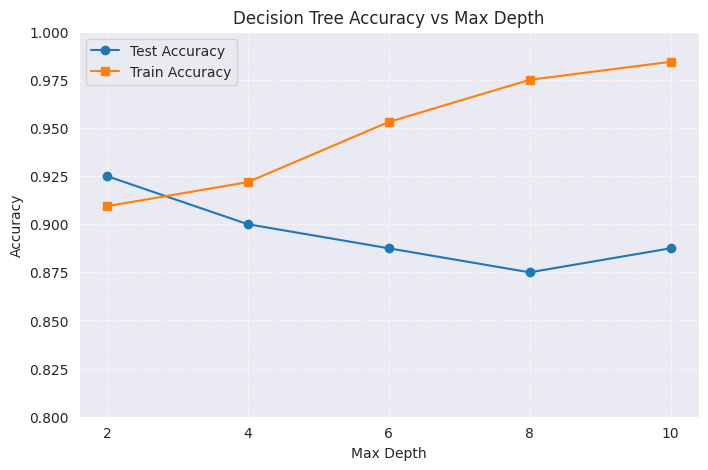

In [9]:
plot_df = train_df.copy()
plot_df["Max Depth"] = pd.to_numeric(plot_df["Max Depth"])
plot_df = plot_df.sort_values("Max Depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["Max Depth"], plot_df["Test_Accuracy"], marker="o", label="Test Accuracy")
plt.plot(plot_df["Max Depth"], plot_df["Train_Accuracy"], marker="s", label="Train Accuracy")

plt.title("Decision Tree Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.xticks(plot_df["Max Depth"])
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

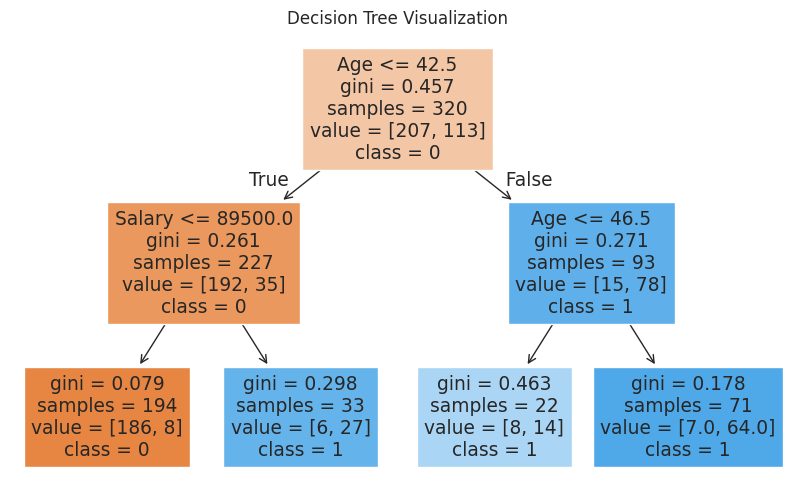

In [10]:
from sklearn import tree

plt.figure(figsize=(10, 6))

tree.plot_tree(
    trained_models[0].classifier,
    filled=True,
    feature_names=df.columns[:-1],
    class_names=np.unique(y).astype(str)
)
plt.title("Decision Tree Visualization")
plt.show()

## Criterion Entropy

In [11]:
max_depth = range(2,11,2)
train_df = pd.DataFrame(columns=['Max Depth', 'Criterion', 'Test_Accuracy', 'Train_Accuracy', 'Classification Report', 'Confusion Matrix'])

trained_models = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(DT_classifier)(X_train, y_train, X_test, y_test, max_depth=depth, criterion='entropy') for depth in max_depth
)

for model in trained_models:
    cr, cm, test_acc, train_acc = model.getReport()
    train_df = pd.concat([train_df, pd.DataFrame({
        'Max Depth': [model.max_depth],
        'Criterion': [model.criterion],
        'Test_Accuracy': [test_acc],
        'Train_Accuracy': [train_acc],
        'Classification Report': [cr],
        'Confusion Matrix': [cm]
    })], ignore_index=True)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.8s finished
/tmp/ipykernel_50123/799872108.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat([train_df, pd.DataFrame({


In [12]:
display(train_df)

,Max Depth,Criterion,Test_Accuracy,Train_Accuracy,Classification Report,Confusion Matrix
0,2,entropy,0.9250,0.909375,precision recall f1-score ...,"[[44, 6], [0, 30]]"
1,4,entropy,0.9000,0.921875,precision recall f1-score ...,"[[46, 4], [4, 26]]"
2,6,entropy,0.8750,0.953125,precision recall f1-score ...,"[[44, 6], [4, 26]]"
3,8,entropy,0.8875,0.968750,precision recall f1-score ...,"[[47, 3], [6, 24]]"
4,10,entropy,0.8875,0.978125,precision recall f1-score ...,"[[46, 4], [5, 25]]"


### Plotting the Outcome

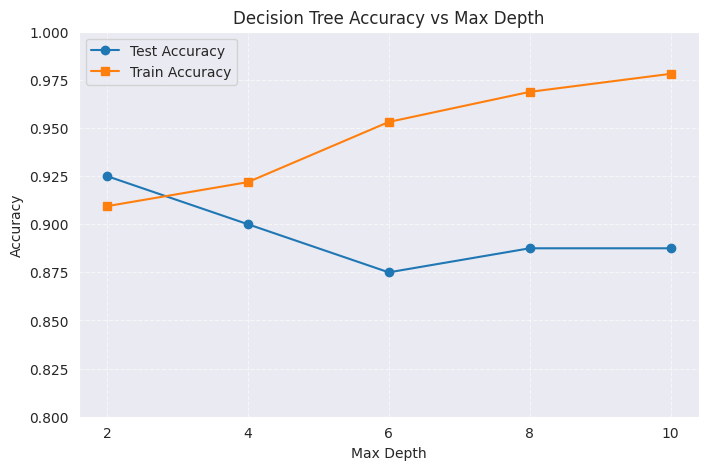

In [13]:
plot_df = train_df.copy()
plot_df["Max Depth"] = pd.to_numeric(plot_df["Max Depth"])
plot_df = plot_df.sort_values("Max Depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["Max Depth"], plot_df["Test_Accuracy"], marker="o", label="Test Accuracy")
plt.plot(plot_df["Max Depth"], plot_df["Train_Accuracy"], marker="s", label="Train Accuracy")

plt.title("Decision Tree Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.xticks(plot_df["Max Depth"])
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

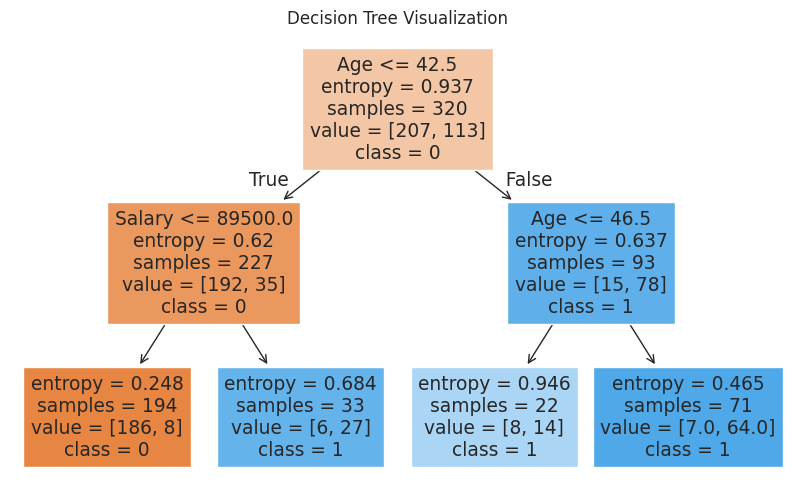

In [14]:
from sklearn import tree

plt.figure(figsize=(10, 6))

tree.plot_tree(
    trained_models[0].classifier,
    filled=True,
    feature_names=df.columns[:-1],
    class_names=np.unique(y).astype(str)
)
plt.title("Decision Tree Visualization")
plt.show()